# Keras Regression Code Along Project

Let's now apply our knowledge to a more realistic data set. Here we will also focus on feature engineering and cleaning our data!

## The Data

We will be using data from a Kaggle data set:

https://www.kaggle.com/harlfoxem/housesalesprediction

#### Feature Columns
    
* id - Unique ID for each home sold
* date - Date of the home sale
* price - Price of each home sold
* bedrooms - Number of bedrooms
* bathrooms - Number of bathrooms, where .5 accounts for a room with a toilet but no shower
* sqft_living - Square footage of the apartments interior living space
* sqft_lot - Square footage of the land space
* floors - Number of floors
* waterfront - A dummy variable for whether the apartment was overlooking the waterfront or not
* view - An index from 0 to 4 of how good the view of the property was
* condition - An index from 1 to 5 on the condition of the apartment,
* grade - An index from 1 to 13, where 1-3 falls short of building construction and design, 7 has an average level of construction and design, and 11-13 have a high quality level of construction and design.
* sqft_above - The square footage of the interior housing space that is above ground level
* sqft_basement - The square footage of the interior housing space that is below ground level
* yr_built - The year the house was initially built
* yr_renovated - The year of the house’s last renovation
* zipcode - What zipcode area the house is in
* lat - Lattitude
* long - Longitude
* sqft_living15 - The square footage of interior housing living space for the nearest 15 neighbors
* sqft_lot15 - The square footage of the land lots of the nearest 15 neighbors

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
df = pd.read_csv('kc_house_data.csv')

# Exploratory Data Analysis

In [23]:
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [24]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
id,21613.0,4.580302e+09,2.876566e+09,1.000102e+06,2.123049e+09,3.904930e+09,7.308900e+09,9.900000e+09
price,21613.0,5.400881e+05,3.671272e+05,7.500000e+04,3.219500e+05,4.500000e+05,6.450000e+05,7.700000e+06
bedrooms,21613.0,3.370842e+00,9.300618e-01,0.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.300000e+01
bathrooms,21613.0,2.114757e+00,7.701632e-01,0.000000e+00,1.750000e+00,2.250000e+00,2.500000e+00,8.000000e+00
sqft_living,21613.0,2.079900e+03,9.184409e+02,2.900000e+02,1.427000e+03,1.910000e+03,2.550000e+03,1.354000e+04
sqft_lot,21613.0,1.510697e+04,4.142051e+04,5.200000e+02,5.040000e+03,7.618000e+03,1.068800e+04,1.651359e+06
floors,21613.0,1.494309e+00,5.399889e-01,1.000000e+00,1.000000e+00,1.500000e+00,2.000000e+00,3.500000e+00
waterfront,21613.0,7.541757e-03,8.651720e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
view,21613.0,2.343034e-01,7.663176e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
condition,21613.0,3.409430e+00,6.507430e-01,1.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00


C:\Users\Huawei\AppData\Local\Temp\ipykernel_8008\352518620.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  insight = sns.distplot(df["price"])


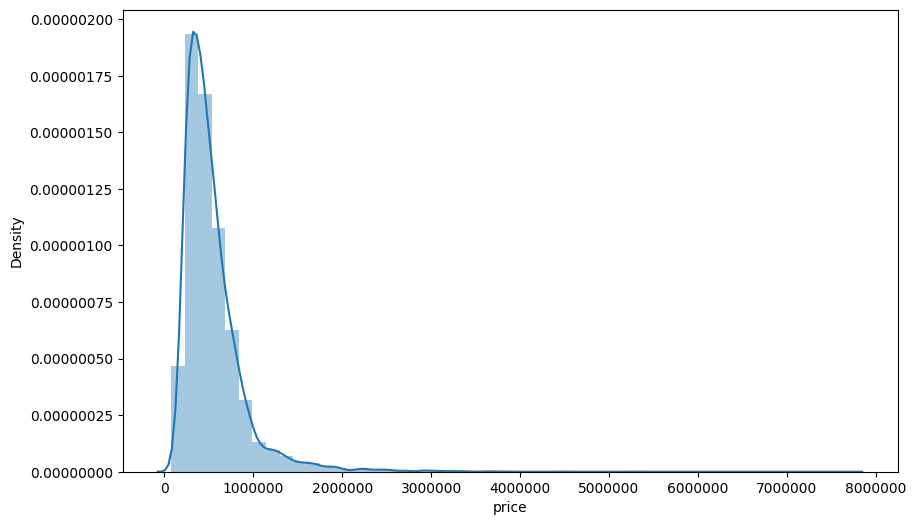

In [25]:
plt.figure(figsize=(10,6))
insight = sns.distplot(df["price"])
insight.ticklabel_format(style='plain', axis='x')
insight.ticklabel_format(style='plain', axis='y')

plt.show()

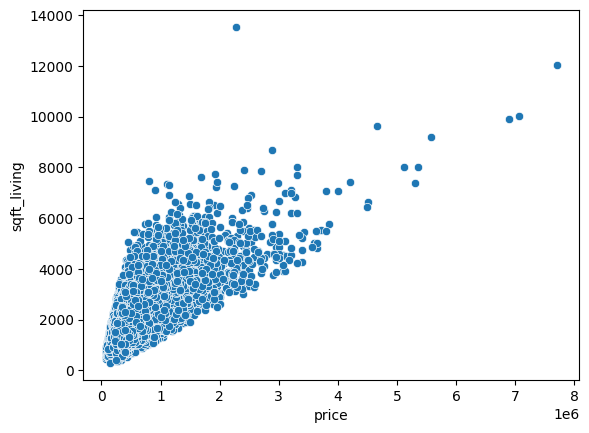

In [26]:
sns.scatterplot(data=df, x="price", y="sqft_living")

plt.xlabel("price")
plt.ylabel("sqft_living")

plt.show()

C:\Users\Huawei\AppData\Local\Temp\ipykernel_18076\1644390233.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='bedrooms', y='price', data=df, palette="Set3")


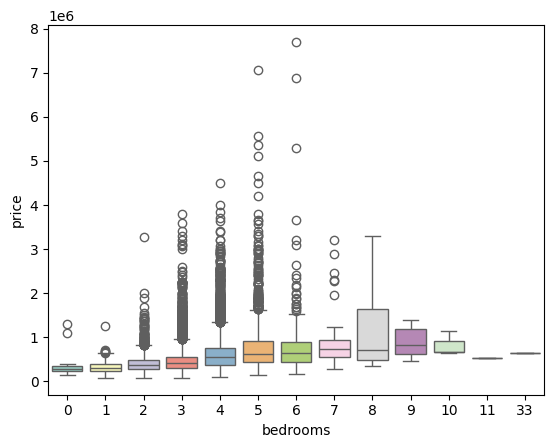

In [7]:
sns.boxplot(x='bedrooms', y='price', data=df, palette="Set3")
insight.ticklabel_format(style='plain', axis='y')
plt.show()

C:\Users\Huawei\AppData\Local\Temp\ipykernel_18076\162494655.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='waterfront',y='price',data=df,  palette="Set3")


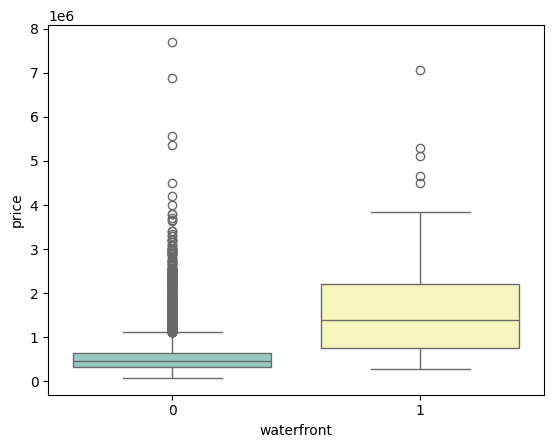

In [8]:
sns.boxplot(x='waterfront',y='price',data=df,  palette="Set3")
insight.ticklabel_format(style='plain', axis='y')
plt.show()

## Working with Feature Data

In [27]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [29]:
df=df.drop('id',axis=1)

In [30]:
df['date'] = pd.to_datetime(df['date'])
df['date'] = df['date'].dt.strftime('%-m/%-d/%Y')

In [31]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,2014-10-13 00:00:00,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,2014-12-09 00:00:00,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,2015-02-25 00:00:00,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2014-12-09 00:00:00,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,2015-02-18 00:00:00,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


#changing type of price


In [32]:
df['price'] = df['price'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           21613 non-null  object 
 1   price          21613 non-null  int64  
 2   bedrooms       21613 non-null  int64  
 3   bathrooms      21613 non-null  float64
 4   sqft_living    21613 non-null  int64  
 5   sqft_lot       21613 non-null  int64  
 6   floors         21613 non-null  float64
 7   waterfront     21613 non-null  int64  
 8   view           21613 non-null  int64  
 9   condition      21613 non-null  int64  
 10  grade          21613 non-null  int64  
 11  sqft_above     21613 non-null  int64  
 12  sqft_basement  21613 non-null  int64  
 13  yr_built       21613 non-null  int64  
 14  yr_renovated   21613 non-null  int64  
 15  zipcode        21613 non-null  int64  
 16  lat            21613 non-null  float64
 17  long           21613 non-null  float64
 18  sqft_l

- There is difference between the dataframes

### Feature Engineering from Date

In [33]:
# make columns for month and year
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].apply(lambda date:date.month)
df['year'] = df['date'].apply(lambda date:date.year)

C:\Users\Huawei\AppData\Local\Temp\ipykernel_8008\3595109806.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='year',y='price',data=df,  palette="Set2")


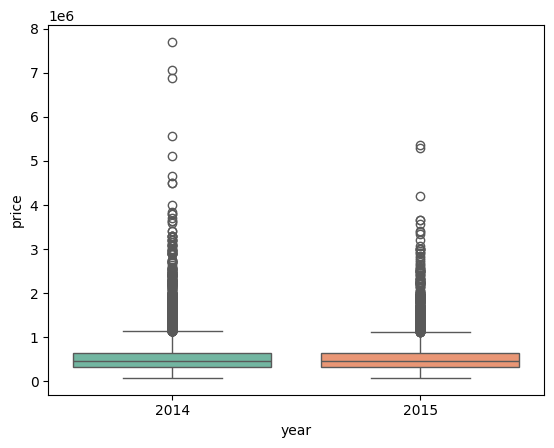

In [34]:
sns.boxplot(x='year',y='price',data=df,  palette="Set2")
plt.show()


C:\Users\Huawei\AppData\Local\Temp\ipykernel_8008\3986915863.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='month',y='price',data=df,  palette="Set2")


<Axes: xlabel='month', ylabel='price'>

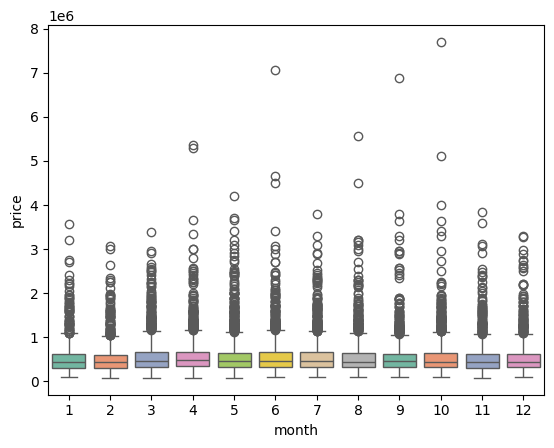

In [35]:
sns.boxplot(x='month',y='price',data=df,  palette="Set2")

In [36]:
#drop date column
df = df.drop('date',axis=1)

In [37]:
df.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'month', 'year'],
      dtype='object')

## Scaling and Train Test Split

In [38]:
from sklearn.model_selection import train_test_split

In [39]:
X = df.drop('price',axis=1)
y = df['price']

In [40]:
print(X.shape[1])
print(X.shape[0])

20
21613


In [41]:
print(X.columns)

Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'month', 'year'],
      dtype='object')


### Scaling

In [42]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)


In [43]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()


In [44]:
scaler.fit(X_train)

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [45]:
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

## Creating a Model

In [46]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras.optimizers import Adam

In [47]:
model = Sequential()

adding hidden layers , we have 19 Neurons because we have 19 features

In [48]:
model.add(Dense(19, activation='relu'))
model.add(Dense(19, activation='relu'))
model.add(Dense(19, activation='relu'))
model.add(Dense(19, activation='relu'))

Output layer ,used 1 only because we do want to predict one number

In [49]:
model.add(Dense(1))


compiling

i will use adam as optimizer ,For error measurment i will use MSE cause our case is regression

(MSA is way to calculate how far the model from the correct answer, less MSE more effiecnt model)

In [50]:
model.compile(optimizer='adam', loss='mse')
# model.compile(optimizer='sgd', loss='mse')



## Training the Model

In [51]:
# from tensorflow.keras.callbacks import EarlyStopping
# early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=25)
# model.fit(x=X_train, y=y_train,
#           epochs=400,
#           validation_data=(X_test, y_test),
#           callbacks=[early_stop])

model.fit(x=X_train,
          y=y_train,
          validation_data=(X_test, y_test),
          batch_size=128,
          epochs=400)



Epoch 1/400
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 423636566016.0000 - val_loss: 433073291264.0000
Epoch 2/400
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 423364165632.0000 - val_loss: 431972974592.0000
Epoch 3/400
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 418038579200.0000 - val_loss: 418481733632.0000
Epoch 4/400
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 385065811968.0000 - val_loss: 356841390080.0000
Epoch 5/400
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 286035378176.0000 - val_loss: 221425451008.0000
Epoch 6/400
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 154614562816.0000 - val_loss: 119383597056.0000
Epoch 7/400
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 104026144768.0000 - val_loss: 106249281536.0000
Epoch 8/400
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 100026990592.0000 - val_loss: 104672329728.0000
Epoch 9/400
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 98709102592.0000 - val_loss: 103284850688.0000
Epoch 10/400
119/119

In [31]:
losses = pd.DataFrame(model.history.history)

i used hybird approach [early stopping + fixed Epoch] , noticed that model not stable yet , RESULT SHOWN :

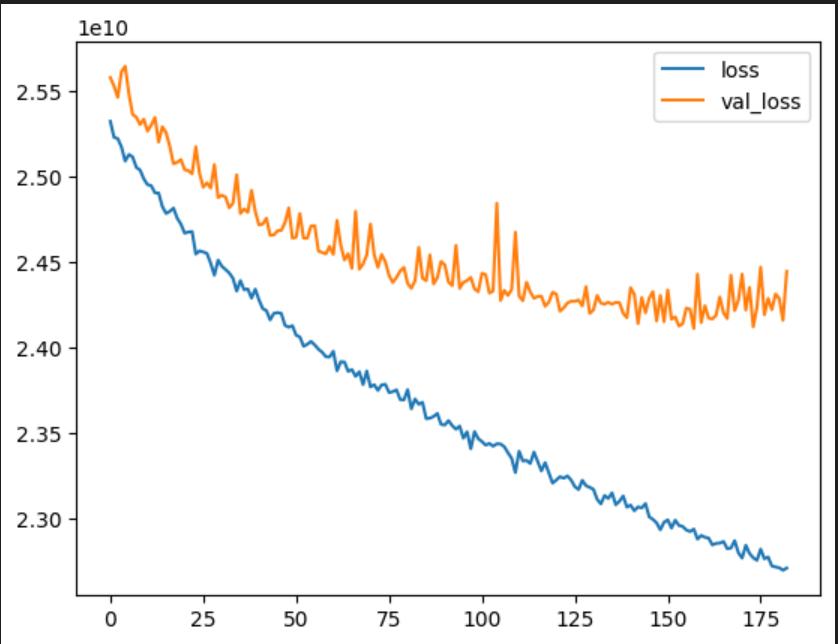

using only fixed Epoch

More Stable Model

<Axes: >

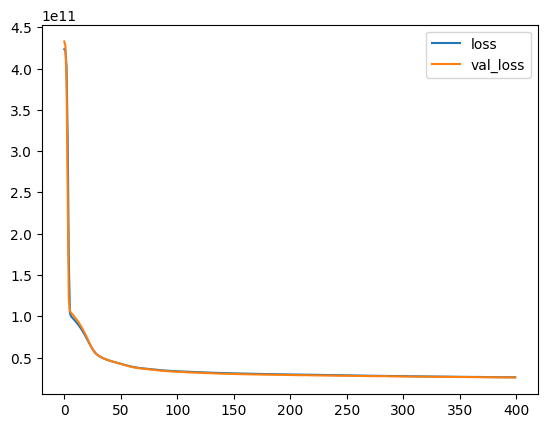

In [33]:
losses.plot()

# Evaluation on Test Data

https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics

In [52]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,explained_variance_score

In [53]:
#asking the model to predict
predictions = model.predict(X_test)

#calculate the MSE
from sklearn.metrics import mean_absolute_error
print(f"MAE: {mean_absolute_error(y_test, predictions)}")
#caculate MAE
print("MSE:", mean_squared_error(y_test, predictions))
#Varience score
from sklearn.metrics import explained_variance_score
print(f"Variance Score: {explained_variance_score(y_test, predictions)}")


203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MAE: 101652.1171875
MSE: 26367201280.0
Variance Score: 0.8121863603591919


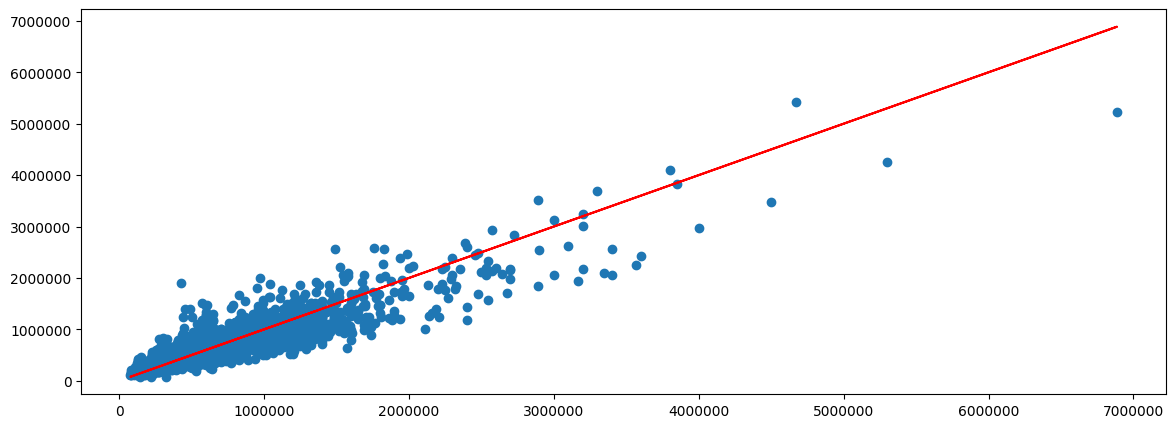

In [36]:
plt.figure(figsize=(14, 5))

plt.scatter(y_test,predictions)
plt.ticklabel_format(style='plain', axis='both')

plt.plot(y_test,y_test,'r')

Saving

In [13]:
import joblib

In [17]:
import pickle
with open('scaler_weights.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("saving DONE!")

saving DONE!


In [58]:

model.save_weights('model_weights.weights.h5') 
model.save('my_house_model.keras')

print("saved !  : keras_house_price_model.h5")


saved !  : keras_house_price_model.h5


In [55]:
model.save('../house_price_model.h5')
print("saved !  : keras_house_price_model.h5")

feature_names = X.columns.tolist()
joblib.dump(feature_names, '../save_models/feature_names.pkl')

saved !  : keras_house_price_model.h5


['../save_models/feature_names.pkl']